### 4: Measures of Shape & Distribution Geometry
While central tendency measures the middle, dispersion measures the spread, and position measures relative rank, **measures of shape** describe the structural geometry, asymmetry, and tail thickness of a distribution.

Below are clear, naive examples covering the core measures of distribution shape, complete with mathematical formulas, notation pronunciations, and Python implementation comparisons across **Plain Python**, **Standard Library `statistics`**, and **`NumPy`** / **`SciPy`**.

--- 
## 1. Skewness (Asymmetry of Distribution)

* **What it does:** Measures the degree and direction of asymmetry in a dataset relative to a normal distribution.
  * **Right/Positive Skew ($g_1 > 0$):** Long tail on the right side ($	ext{Mean} > 	ext{Median} > 	ext{Mode}$).
  * **Symmetric ($g_1 \approx 0$):** Bell-shaped distribution ($	ext{Mean} \approx \text{Median} \approx \text{Mode}$).
  * **Left/Negative Skew ($g_1 < 0$):** Long tail on the left side ($	ext{Mean} < \text{Median} < \text{Mode}$).
* **Mathematical Notation:**
  $$g_1 = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{s^3} = \frac{m_3}{s^3}$$
  *Where:*
  * $g_1$ (*g one*): Sample skewness coefficient
  * $m_3$ (*m three*): 3rd central moment (cubed deviations)
  * $s^3$ (*s cubed*): Sample standard deviation cubed
  * $\bar{x}$ (*x-bar*): Sample mean
* **Naive Example:** Salary distribution in a startup (in $1,000s): `[30, 35, 40, 45, 250]` ($n = 5$). Average is pulled up to 84 by the CEO's 250 salary, creating a strong right tail.
  $$g_1 \approx +1.48 \quad (\text{Strong Positive / Right Skew})$$
* **When to use:** Evaluating normativity before regression analysis, wealth/income datasets, and selecting between Mean vs Median.

In [9]:
import math
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics

Plain Python (Population Skewness): +1.487
SciPy stats.skew (bias=True):       +1.487
SciPy stats.skew (bias=False):      +2.217


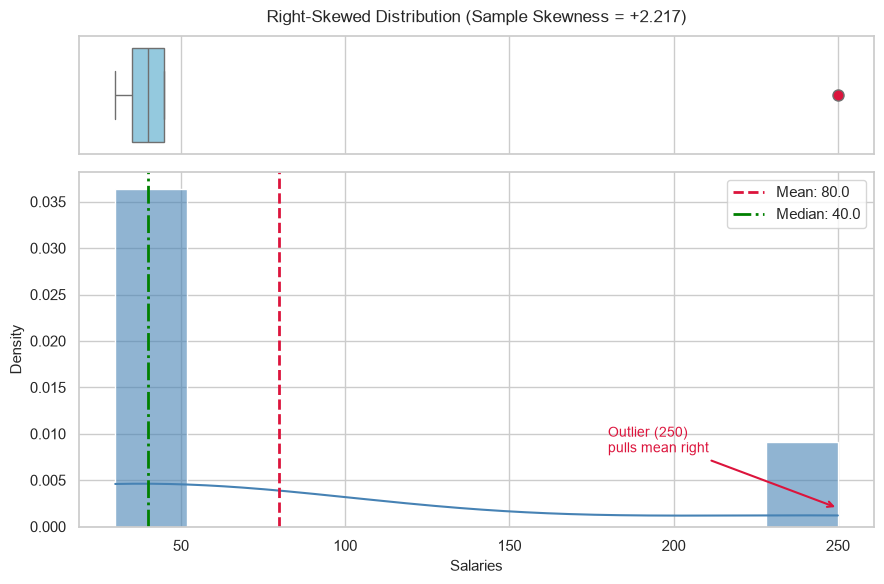

In [4]:

# 1. Skewness Example
salaries = [30, 35, 40, 45, 250]
n = len(salaries)

# Plain Python
median_val = np.median(salaries)
mean_val = sum(salaries) / n
var_val = sum((x - mean_val) ** 2 for x in salaries) / n
std_val = math.sqrt(var_val)
m3 = sum((x - mean_val) ** 3 for x in salaries) / n
skew_python = m3 / (std_val ** 3)

# SciPy Library
# bias=True calculates population skewness; bias=False applies sample correction
skew_scipy_pop = stats.skew(salaries, bias=True)
skew_scipy_sample = stats.skew(salaries, bias=False)

# + indicates right skew, - indicates left skew

print(f"Plain Python (Population Skewness): {skew_python:+.3f}")  # +ve indicates right skew, -ve indicates left skew
print(f"SciPy stats.skew (bias=True):       {skew_scipy_pop:+.3f}")  # +ve indicates right skew, -ve indicates left skew
print(f"SciPy stats.skew (bias=False):      {skew_scipy_sample:+.3f}")  # +ve indicates right skew, -ve indicates left skew


# 2. Visualization Setup
sns.set_theme(style="whitegrid")
fig, (ax_box, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [0.25, 0.75]},
)

# Top Plot: Boxplot (Highlights the extreme outlier at 250)
sns.boxplot(x=salaries, ax=ax_box, color="skyblue", flierprops={"markerfacecolor": "crimson", "markersize": 8})
ax_box.set(xlabel="")
ax_box.set_title(
    f"Right-Skewed Distribution (Sample Skewness = {skew_scipy_sample:+.3f})",
    fontsize=12,
    pad=10,
)

# Bottom Plot: Histogram + Kernel Density Estimate (KDE)
sns.histplot(salaries, kde=True, ax=ax_hist, color="steelblue", bins=10, stat="density", alpha=0.6)

# Annotate Mean vs Median to show the effect of the outlier on skewness
ax_hist.axvline(mean_val, color="crimson", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
ax_hist.axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_val:.1f}")

# Annotate Outlier Point
ax_hist.annotate(
    "Outlier (250)\npulls mean right",
    xy=(250, 0.002),
    xytext=(180, 0.008),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5),
    fontsize=10,
    color="crimson",
)

ax_hist.set_xlabel("Salaries", fontsize=11)
ax_hist.set_ylabel("Density", fontsize=11)
ax_hist.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

---
## 2. Kurtosis & Excess Kurtosis (Tail Thickness & Extremity)
* **What it does:** Measures tail weight and the likelihood of extreme outliers compared to a normal distribution.
  * **Leptokurtic (Excess Kurtosis $> 0$):** Heavy tails, high outlier risk (e.g., financial markets).
  * **Mesokurtic (Excess Kurtosis \approx 0$):** Normal distribution tails (Gaussian bell curve).
  * **Platykurtic (Excess Kurtosis $< 0$):** Thin tails, uniform spread, rare outliers.
* **Mathematical Notation:**
  $$\text{Kurtosis} = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4}{s^4} = \frac{m_4}{s^4}$$
  $$\text{Excess Kurtosis} = \text{Kurtosis} - 3$$
  *Where:*
  * $m_4$ (*m four*): 4th central moment (fourth-power deviations)
  * $s^4$ (*s to the 4th*): Standard deviation raised to 4th power
  * $-3$ (*minus three*): Baseline subtraction so normal distribution equals 0
* **Naive Example:** Stock daily returns in percentage: `[-10, -0.5, 0, 0.5, 12]` ($n = 5$). Presence of extreme +/-10% days creates heavy tails.
  $$\text{Excess Kurtosis} \approx +0.12 \quad (\text{Leptokurtic / Heavy-Tailed})$$
* **When to use:** Financial risk management (Value at Risk), quality control anomaly detection, and robust statistical testing.

Plain Python (Excess Kurtosis):    -0.491
SciPy Excess Kurtosis (fisher=True): -0.491
SciPy Raw Kurtosis (fisher=False):   +2.509


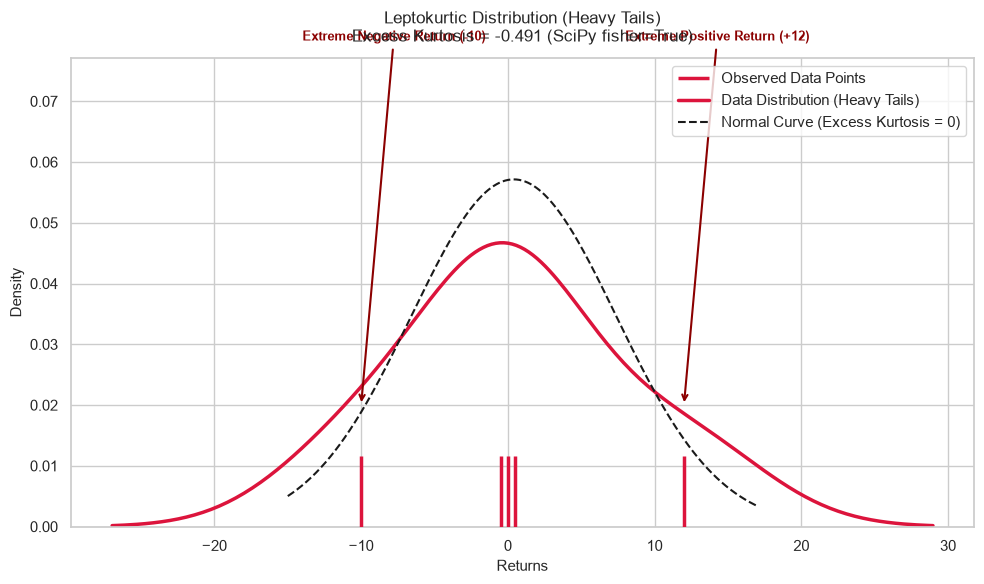

In [7]:
# 2. Excess Kurtosis Example
returns = [-10, -0.5, 0, 0.5, 12]
n = len(returns)

# Plain Python
mean_val = sum(returns) / n
var_val = sum((x - mean_val) ** 2 for x in returns) / n
std_val = math.sqrt(var_val)
m4 = sum((x - mean_val) ** 4 for x in returns) / n
kurtosis_raw = m4 / (std_val ** 4)
excess_kurtosis_python = kurtosis_raw - 3.0

# SciPy Library (fisher=True calculates Excess Kurtosis relative to 3.0)
excess_kurt_scipy = stats.kurtosis(returns, fisher=True, bias=True)
raw_kurt_scipy = stats.kurtosis(returns, fisher=False, bias=True)

print(f"Plain Python (Excess Kurtosis):    {excess_kurtosis_python:+.3f}")
print(f"SciPy Excess Kurtosis (fisher=True): {excess_kurt_scipy:+.3f}")
print(f"SciPy Raw Kurtosis (fisher=False):   {raw_kurt_scipy:+.3f}")


# 2. Visualization Setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points as vertical markers (rug plot) and kernel density
# rugplot : Displays individual data points along the x-axis as small vertical lines, providing a visual representation of the distribution of the data.
sns.rugplot(returns, ax=ax, color="crimson", height=0.15, linewidth=2.5, label="Observed Data Points", zorder=5)
sns.kdeplot(returns, ax=ax, color="crimson", linewidth=2.5, label="Data Distribution (Heavy Tails)")
# kde : Kernel Density Estimate provides a smooth estimate of the probability density function of the returns.

# Overlay a reference Normal Distribution with same mean & std for comparison
x_range = np.linspace(min(returns) - 5, max(returns) + 5, 500)
norm_pdf = stats.norm.pdf(x_range, loc=mean_val, scale=std_val)
ax.plot(x_range, norm_pdf, "k--", linewidth=1.5, label=f"Normal Curve (Excess Kurtosis = 0)")

# Annotate Extreme Tail Outliers contributing to high m4
ax.annotate(
    "Extreme Negative Return (-10)",
    xy=(-10, 0.02),
    xytext=(-14, 0.08),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=9.5,
    color="darkred",
    fontweight="bold",
)

ax.annotate(
    "Extreme Positive Return (+12)",
    xy=(12, 0.02),
    xytext=(8, 0.08),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=9.5,
    color="darkred",
    fontweight="bold",
)

# Plot Details
ax.set_title(
    f"Leptokurtic Distribution (Heavy Tails)\nExcess Kurtosis = {excess_kurt_scipy:+.3f} (SciPy fisher=True)",
    fontsize=12,
    pad=12,
)
ax.set_xlabel("Returns", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

--- 
#### 3. Pearson's Median Skewness Coefficient (Robust Non-Parametric Skew)

* **What it does:** Calculates a quick, intuitive measure of skewness based on the distance between mean and median, scaled by standard deviation.
* **Mathematical Notation:**
  $$SK_p = \frac{3(\bar{x} - \tilde{x})}{s}$$

  $$\text{Pearson's Median Skewness} = \frac{3 \times (\text{Mean} - \text{Median})}{\text{Standard Deviation}}$$
  *Where:*
  * $SK_p$ (*Pearson's Skewness*): Non-parametric skewness index (typically ranges between -3 and +3)
  * $\bar{x}$ (*x-bar*): Sample mean
  * $\tilde{x}$ (*x-tilde*): Sample median
  * $s$ (*s*): Sample standard deviation
* **Naive Example:** Customer review wait times in minutes: `[2, 3, 3, 4, 20]` ($\bar{x} = 6.4, \tilde{x} = 3, s \approx 7.67$).
  $$SK_p = \frac{3(6.4 - 3)}{7.67} = \frac{10.2}{7.67} \approx +1.33$$
* **When to use:** Fast Exploratory Data Analysis (EDA) when 3rd moments are sensitive to extreme measurement noise.

Mean:   6.40 mins
Median: 3.00 mins
Pearson's Skewness (Python): +1.336
Pearson's Skewness (NumPy):  +1.336


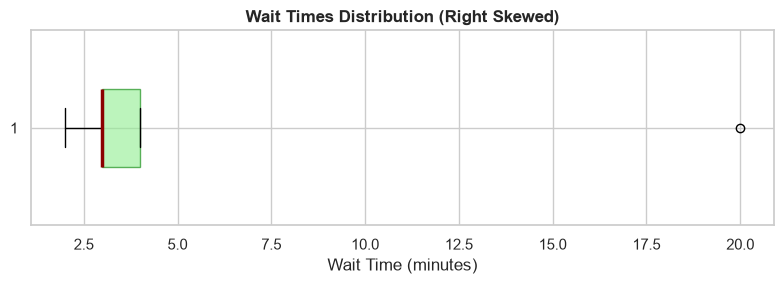

In [10]:



# 3. Pearson's Median Skewness Example
wait_times = [2, 3, 3, 4, 20]

# Plain Python / Standard Library
mean_val = statistics.mean(wait_times)
median_val = statistics.median(wait_times)
std_val = statistics.stdev(wait_times)
pearsons_skew_py = (3 * (mean_val - median_val)) / std_val

# NumPy Vector Operations
np_data = np.array(wait_times)
pearsons_skew_np = (3 * (np.mean(np_data) - np.median(np_data))) / np.std(np_data, ddof=1)

print(f"Mean:   {mean_val:.2f} mins")
print(f"Median: {median_val:.2f} mins")
print(f"Pearson's Skewness (Python): {pearsons_skew_py:+.3f}")
print(f"Pearson's Skewness (NumPy):  {pearsons_skew_np:+.3f}")

# Horizontal Boxplot Visualization using orientation parameter
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot(wait_times, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightgreen', color='green', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))
ax.set_title("Wait Times Distribution (Right Skewed)", fontweight='bold')
ax.set_xlabel("Wait Time (minutes)")
plt.tight_layout()
plt.show()

# Pearson's Median Skewness

Pearson's Median Skewness measures the asymmetry of a distribution based on the distance between the mean and median:

$$\text{Pearson's Skewness} = \frac{3 \times (\text{Mean} - \text{Median})}{\sigma}$$

---

### Sign Interpretation

| Skewness | Condition | Distribution | Tail Direction | Practical Meaning |
| :--- | :--- | :--- | :--- | :--- |
| **Positive ($> 0$)** | $\text{Mean} > \text{Median}$ | **Right-Skewed** | Long tail to the **Right** | High outliers drag the mean above the median |
| **Zero ($= 0$)** | $\text{Mean} = \text{Median}$ | **Symmetric** | Equal tails | Perfectly balanced around center |
| **Negative ($< 0$)** | $\text{Mean} < \text{Median}$ | **Left-Skewed** | Long tail to the **Left** | Low outliers drag the mean below the median |

---

### Result Interpretation (+1.336)

* **Sign (+):** Indicates **Right-skewed data** ($\text{Mean } 6.40 > \text{Median } 3.00$).
* **Magnitude (1.336):** Since $\vert{}1.336\vert{} > 1.0$, the distribution is **strongly skewed**.
* **Recommendation:** Use the **Median ($3.00\text{ mins}$)** rather than the Mean ($6.40\text{ mins}$) to describe typical performance.